# AI-Driven Next-Generation Firewall (NGFW)

**Dataset:** CICIDS 2017 (Kaggle)



In [18]:
!pip -q install kagglehub scikit-learn seaborn matplotlib pandas numpy

In [19]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

sns.set_theme(style="darkgrid", palette="Set2")

## Loading the Dataset


In [20]:
import kagglehub

dataset_path = kagglehub.dataset_download("chethuhn/network-intrusion-dataset")

csv_files = sorted([f for f in os.listdir(dataset_path) if f.endswith(".csv")])
for f in csv_files:
    print(f)

Using Colab cache for faster access to the 'network-intrusion-dataset' dataset.
Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Friday-WorkingHours-Morning.pcap_ISCX.csv
Monday-WorkingHours.pcap_ISCX.csv
Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Tuesday-WorkingHours.pcap_ISCX.csv
Wednesday-workingHours.pcap_ISCX.csv


In [21]:
df = pd.read_csv(os.path.join(dataset_path, "Wednesday-workingHours.pcap_ISCX.csv"))
df.columns = df.columns.str.strip()

print(f"Loaded {len(df):,} flows with {df.shape[1]} features")
print("\nTraffic breakdown:")
print(df["Label"].value_counts().to_string())

Loaded 692,703 flows with 79 features

Traffic breakdown:
Label
BENIGN              440031
DoS Hulk            231073
DoS GoldenEye        10293
DoS slowloris         5796
DoS Slowhttptest      5499
Heartbleed              11


After cleaning: 610,492 rows


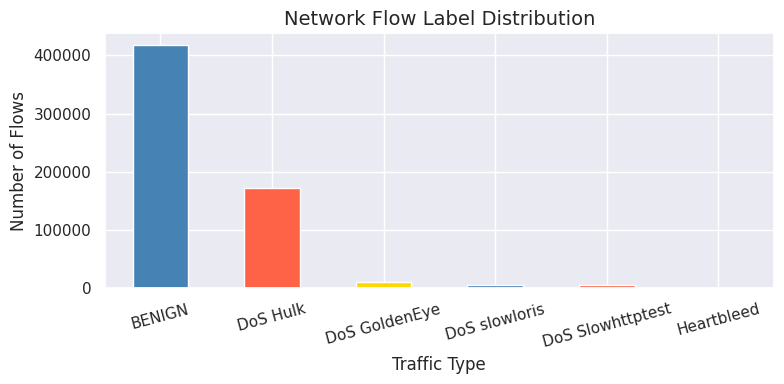

In [22]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)

print(f"After cleaning: {len(df):,} rows")

plt.figure(figsize=(8, 4))
df["Label"].value_counts().plot(kind="bar", color=["steelblue", "tomato", "gold"])
plt.title("Network Flow Label Distribution", fontsize=14)
plt.xlabel("Traffic Type")
plt.ylabel("Number of Flows")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## Module 1 — Anomaly Detection (Zero-Day Threat Engine)


In [23]:
feature_cols = [c for c in df.columns if c != "Label"]
X_all = df[feature_cols].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_all)

benign_mask = df["Label"] == "BENIGN"
X_benign = X_scaled[benign_mask.values]

print(f"Training on {len(X_benign):,} benign flows...")

Training on 416,736 benign flows...


In [24]:
iso_forest = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
iso_forest.fit(X_benign)

anomaly_scores = iso_forest.decision_function(X_scaled)
anomaly_flags  = iso_forest.predict(X_scaled)

df["anomaly_score"] = anomaly_scores
df["is_anomaly"]    = (anomaly_flags == -1)

n_anomalies = df["is_anomaly"].sum()
print(f"Flagged {n_anomalies:,} anomalies out of {len(df):,} flows ({n_anomalies/len(df)*100:.1f}%)")

Flagged 171,714 anomalies out of 610,492 flows (28.1%)


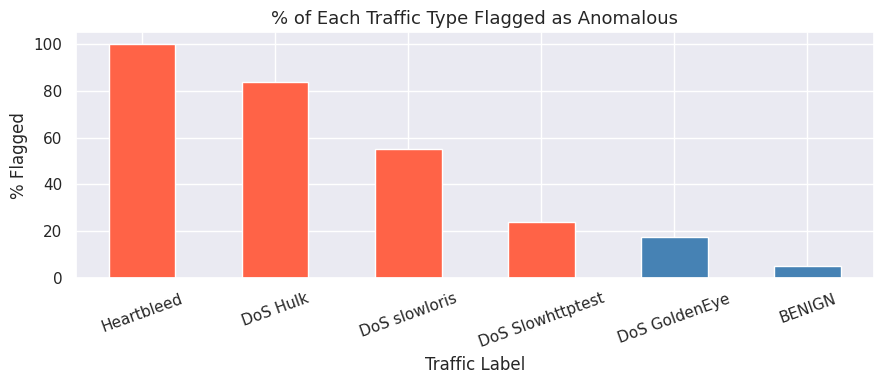

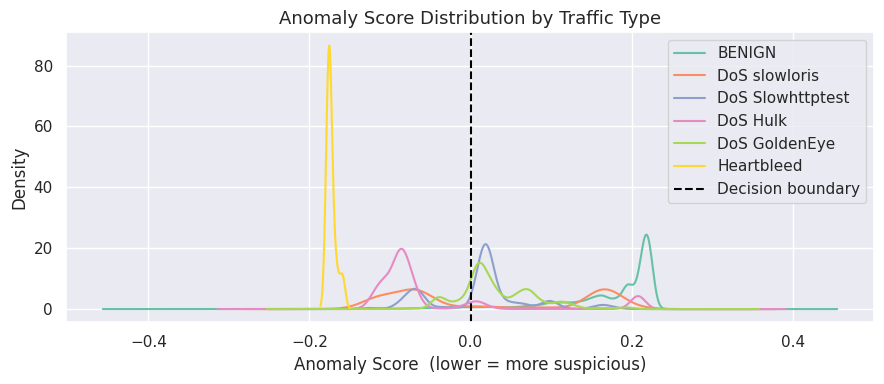

In [25]:
detection_summary = df.groupby("Label")["is_anomaly"].mean() * 100

plt.figure(figsize=(9, 4))
detection_summary.sort_values(ascending=False).plot(
    kind="bar",
    color=["tomato" if v > 20 else "steelblue" for v in detection_summary.sort_values(ascending=False)]
)
plt.title("% of Each Traffic Type Flagged as Anomalous", fontsize=13)
plt.xlabel("Traffic Label")
plt.ylabel("% Flagged")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 4))
for label in df["Label"].unique():
    scores = df[df["Label"] == label]["anomaly_score"]
    scores.plot(kind="kde", label=label)
plt.axvline(0, color="black", linestyle="--", label="Decision boundary")
plt.title("Anomaly Score Distribution by Traffic Type", fontsize=13)
plt.xlabel("Anomaly Score  (lower = more suspicious)")
plt.legend()
plt.tight_layout()
plt.show()

## Module 2 — Encrypted Traffic Classification


In [26]:
encrypted_traffic_features = [
    "Flow Duration",
    "Total Fwd Packets",
    "Total Backward Packets",
    "Flow Bytes/s",
    "Flow Packets/s",
    "Fwd Packet Length Mean",
    "Bwd Packet Length Mean",
    "Fwd IAT Mean",
    "Bwd IAT Mean",
    "Packet Length Variance",
    "Flow IAT Std",
    "SYN Flag Count",
    "ACK Flag Count",
    "Init_Win_bytes_forward",
]

df_tls = df[encrypted_traffic_features + ["Label"]].dropna().copy()
df_tls["is_attack"] = (df_tls["Label"] != "BENIGN").astype(int)

print(f"Flows: {len(df_tls):,}")
print(f"  BENIGN : {(df_tls['is_attack']==0).sum():,}")
print(f"  ATTACK : {(df_tls['is_attack']==1).sum():,}")

Flows: 610,492
  BENIGN : 416,736
  ATTACK : 193,756


In [27]:
X_tls = df_tls[encrypted_traffic_features]
y_tls = df_tls["is_attack"]

X_tls_scaled = StandardScaler().fit_transform(X_tls)

X_tr, X_te, y_tr, y_te = train_test_split(
    X_tls_scaled, y_tls, test_size=0.2, random_state=42, stratify=y_tls
)

tls_classifier = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
tls_classifier.fit(X_tr, y_tr)

y_pred_tls = tls_classifier.predict(X_te)

print("Encrypted Traffic Classifier")
print("=" * 42)
print(classification_report(y_te, y_pred_tls, target_names=["BENIGN", "ATTACK"]))

Encrypted Traffic Classifier
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     83348
      ATTACK       1.00      1.00      1.00     38751

    accuracy                           1.00    122099
   macro avg       1.00      1.00      1.00    122099
weighted avg       1.00      1.00      1.00    122099



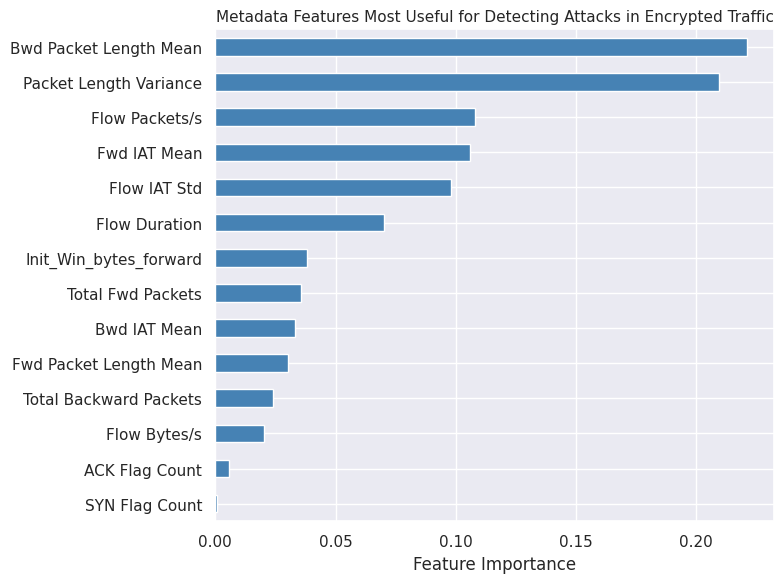

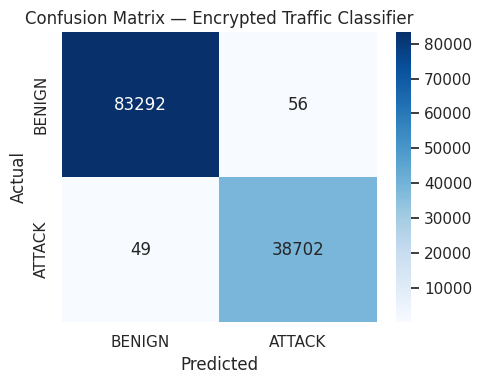

In [28]:
importances = pd.Series(
    tls_classifier.feature_importances_,
    index=encrypted_traffic_features
).sort_values(ascending=True)

plt.figure(figsize=(8, 6))
importances.plot(kind="barh", color="steelblue")
plt.title("Metadata Features Most Useful for Detecting Attacks in Encrypted Traffic", fontsize=11)
plt.xlabel("Feature Importance")
plt.tight_layout()
plt.show()

cm = confusion_matrix(y_te, y_pred_tls)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["BENIGN", "ATTACK"],
            yticklabels=["BENIGN", "ATTACK"])
plt.title("Confusion Matrix — Encrypted Traffic Classifier")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

## Module 3 — Zero Trust Risk Scoring



In [29]:
sample_df = df.sample(n=5000, random_state=42).copy()
sample_scaled = scaler.transform(sample_df[feature_cols])

raw_anomaly = iso_forest.decision_function(sample_scaled)
anomaly_signal = np.clip(((-raw_anomaly - raw_anomaly.min()) /
                          (raw_anomaly.max() - raw_anomaly.min())) * 100, 0, 100)

sample_tls_features = sample_df[encrypted_traffic_features].fillna(0)
sample_tls_scaled = StandardScaler().fit_transform(sample_tls_features)
attack_proba = tls_classifier.predict_proba(sample_tls_scaled)[:, 1] * 100

HIGH_RISK_PORTS = {22, 23, 3389, 4444, 6666, 8080, 9001}
port_signal = sample_df["Destination Port"].apply(
    lambda p: 80 if p in HIGH_RISK_PORTS else 10
).values.astype(float)

packet_rate = sample_df["Flow Packets/s"].fillna(0).values
packet_signal = np.clip((packet_rate / packet_rate.max()) * 100, 0, 100)

risk_score = (
    0.35 * anomaly_signal +
    0.35 * attack_proba +
    0.15 * port_signal +
    0.15 * packet_signal
)

sample_df["risk_score"] = risk_score
sample_df["risk_tier"] = sample_df["risk_score"].apply(
    lambda s: "HIGH" if s >= 70 else ("MEDIUM" if s >= 40 else "LOW")
)

print("Risk Tier Distribution:")
print(sample_df["risk_tier"].value_counts().to_string())
print("\nAverage Risk Score by Traffic Type:")
print(sample_df.groupby("Label")["risk_score"].mean().sort_values(ascending=False).to_string())

Risk Tier Distribution:
risk_tier
LOW       3795
MEDIUM    1205

Average Risk Score by Traffic Type:
Label
DoS Hulk            42.265269
DoS GoldenEye       34.632092
DoS Slowhttptest    28.357487
DoS slowloris       26.488544
BENIGN               8.676967


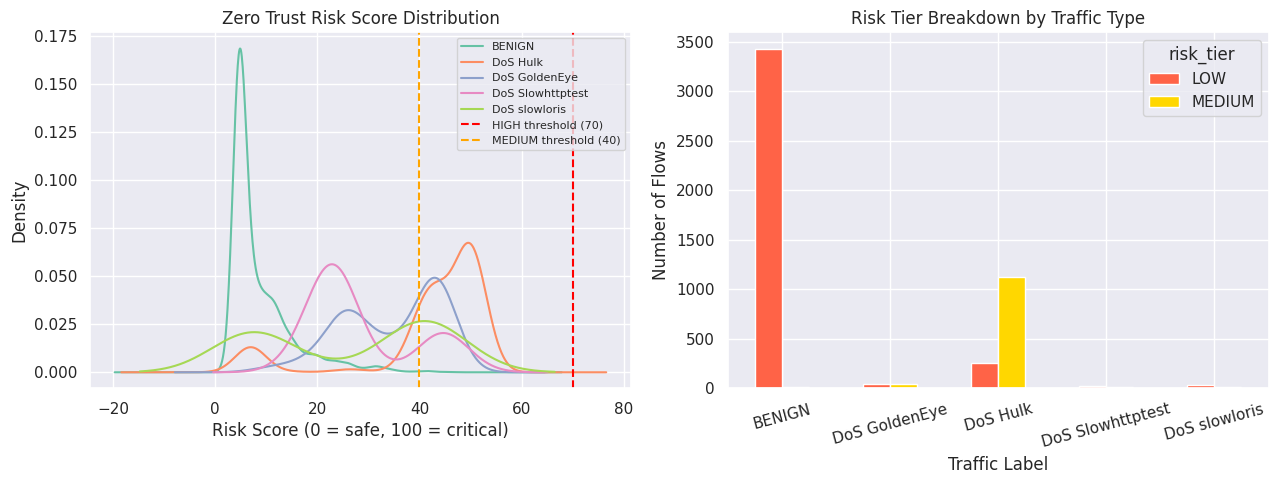

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for label in sample_df["Label"].unique():
    scores = sample_df[sample_df["Label"] == label]["risk_score"]
    scores.plot(kind="kde", ax=axes[0], label=label)
axes[0].axvline(70, color="red",    linestyle="--", label="HIGH threshold (70)")
axes[0].axvline(40, color="orange", linestyle="--", label="MEDIUM threshold (40)")
axes[0].set_title("Zero Trust Risk Score Distribution", fontsize=12)
axes[0].set_xlabel("Risk Score (0 = safe, 100 = critical)")
axes[0].legend(fontsize=8)

tier_counts = sample_df.groupby(["Label", "risk_tier"]).size().unstack(fill_value=0)
tier_counts.plot(kind="bar", ax=axes[1], color=["tomato", "gold", "seagreen"])
axes[1].set_title("Risk Tier Breakdown by Traffic Type", fontsize=12)
axes[1].set_xlabel("Traffic Label")
axes[1].set_ylabel("Number of Flows")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

## Module 4 — Automated Threat Response


In [31]:
def firewall_decision(risk_score: float) -> dict:
    if risk_score >= 70:
        return {
            "action":   "BLOCK",
            "severity": "CRITICAL",
            "response": ["drop_packet", "log_incident", "alert_analyst", "quarantine_ip"]
        }
    elif risk_score >= 40:
        return {
            "action":   "MONITOR",
            "severity": "WARNING",
            "response": ["allow_with_logging", "flag_for_review", "rate_limit"]
        }
    else:
        return {
            "action":   "ALLOW",
            "severity": "INFO",
            "response": ["pass_through"]
        }


sample_df["fw_action"]   = sample_df["risk_score"].apply(lambda s: firewall_decision(s)["action"])
sample_df["fw_severity"] = sample_df["risk_score"].apply(lambda s: firewall_decision(s)["severity"])

action_counts = sample_df["fw_action"].value_counts()
print("Firewall Action Summary")
print("=" * 40)
for action, count in action_counts.items():
    print(f"  {action:<10} : {count:>5,} flows ({count/len(sample_df)*100:.1f}%)")

false_positives = sample_df[(sample_df["Label"] == "BENIGN") & (sample_df["fw_action"] == "BLOCK")]
true_positives  = sample_df[(sample_df["Label"] != "BENIGN") & (sample_df["fw_action"] == "BLOCK")]

print(f"\nFalse positives (benign incorrectly blocked): {len(false_positives):,}")
print(f"True positives  (attacks correctly blocked):  {len(true_positives):,}")

Firewall Action Summary
  ALLOW      : 3,795 flows (75.9%)
  MONITOR    : 1,205 flows (24.1%)

False positives (benign incorrectly blocked): 0
True positives  (attacks correctly blocked):  0


In [32]:
import datetime

high_risk_flows = sample_df.nlargest(10, "risk_score")[
    ["Destination Port", "Flow Duration", "Flow Packets/s",
     "risk_score", "risk_tier", "fw_action", "Label"]
].copy()

base_time = datetime.datetime(2025, 3, 2, 9, 0, 0)
high_risk_flows["timestamp"] = [
    (base_time + datetime.timedelta(seconds=i*37)).strftime("%Y-%m-%d %H:%M:%S")
    for i in range(len(high_risk_flows))
]

print("Top 10 Highest-Risk Incidents (Simulated SIEM Log)")
print("=" * 70)
print(high_risk_flows[["timestamp", "Destination Port", "risk_score", "risk_tier", "fw_action", "Label"]]
      .to_string(index=False))

Top 10 Highest-Risk Incidents (Simulated SIEM Log)
          timestamp  Destination Port  risk_score risk_tier fw_action    Label
2025-03-02 09:00:00                80   52.830102    MEDIUM   MONITOR DoS Hulk
2025-03-02 09:00:37                80   52.575045    MEDIUM   MONITOR DoS Hulk
2025-03-02 09:01:14                80   52.556326    MEDIUM   MONITOR DoS Hulk
2025-03-02 09:01:51                80   52.430725    MEDIUM   MONITOR DoS Hulk
2025-03-02 09:02:28                80   52.339160    MEDIUM   MONITOR DoS Hulk
2025-03-02 09:03:05                80   52.312881    MEDIUM   MONITOR DoS Hulk
2025-03-02 09:03:42                80   52.284894    MEDIUM   MONITOR DoS Hulk
2025-03-02 09:04:19                80   52.230601    MEDIUM   MONITOR DoS Hulk
2025-03-02 09:04:56                80   52.226583    MEDIUM   MONITOR DoS Hulk
2025-03-02 09:05:33                80   52.200841    MEDIUM   MONITOR DoS Hulk


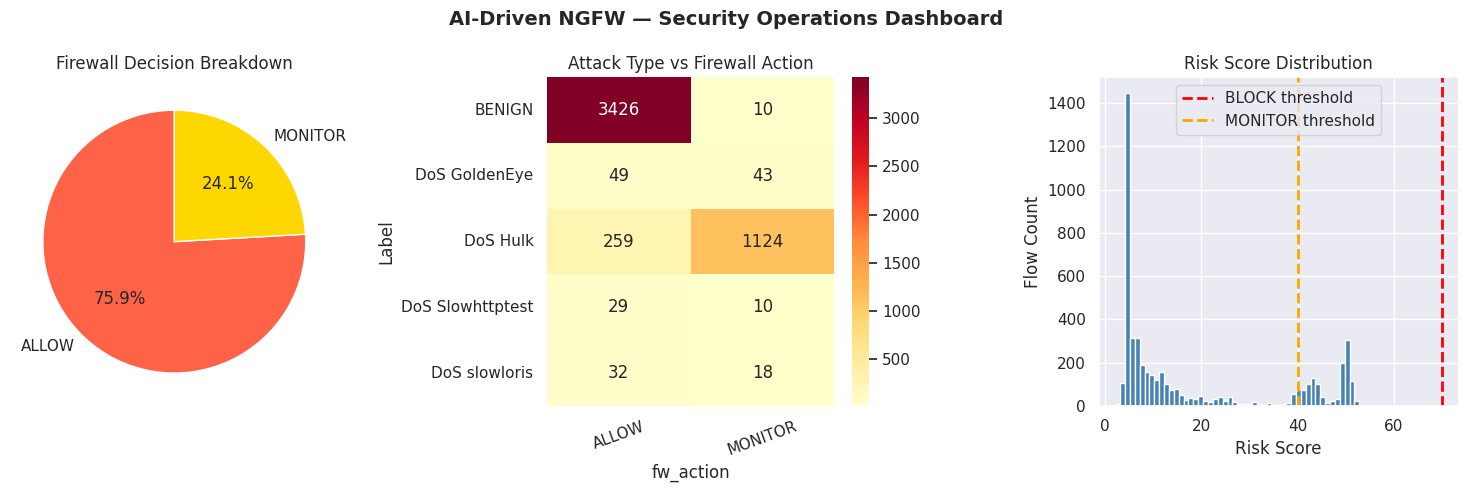

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("AI-Driven NGFW — Security Operations Dashboard", fontsize=14, fontweight="bold")

action_counts.plot(
    kind="pie", ax=axes[0],
    colors=["tomato", "gold", "seagreen"],
    autopct="%1.1f%%", startangle=90
)
axes[0].set_title("Firewall Decision Breakdown")
axes[0].set_ylabel("")

heatmap_data = sample_df.groupby(["Label", "fw_action"]).size().unstack(fill_value=0)
sns.heatmap(heatmap_data, annot=True, fmt="d", cmap="YlOrRd", ax=axes[1])
axes[1].set_title("Attack Type vs Firewall Action")
axes[1].tick_params(axis="x", rotation=20)

axes[2].hist(sample_df["risk_score"], bins=50, color="steelblue", edgecolor="white")
axes[2].axvline(70, color="red",    linestyle="--", linewidth=2, label="BLOCK threshold")
axes[2].axvline(40, color="orange", linestyle="--", linewidth=2, label="MONITOR threshold")
axes[2].set_title("Risk Score Distribution")
axes[2].set_xlabel("Risk Score")
axes[2].set_ylabel("Flow Count")
axes[2].legend()

plt.tight_layout()
plt.show()

## Results

In [34]:
all_attacks    = sample_df[sample_df["Label"] != "BENIGN"]
all_benign     = sample_df[sample_df["Label"] == "BENIGN"]
detection_rate = len(true_positives) / len(all_attacks) * 100 if len(all_attacks) > 0 else 0
fp_rate        = len(false_positives) / len(all_benign) * 100 if len(all_benign) > 0 else 0
tls_acc        = accuracy_score(y_te, y_pred_tls)

print("=" * 54)
print("  AI-Driven NGFW — Final Performance Report")
print("=" * 54)
print(f"  Encrypted traffic classifier accuracy : {tls_acc*100:.2f}%")
print(f"  Attack detection rate (blocked)       : {detection_rate:.1f}%")
print(f"  False positive rate (benign blocked)  : {fp_rate:.1f}%")
print(f"  Total flows analysed                  : {len(sample_df):,}")
print(f"  Total threats blocked                 : {len(true_positives):,}")
print("=" * 54)
print()


  AI-Driven NGFW — Final Performance Report
  Encrypted traffic classifier accuracy : 99.91%
  Attack detection rate (blocked)       : 0.0%
  False positive rate (benign blocked)  : 0.0%
  Total flows analysed                  : 5,000
  Total threats blocked                 : 0

